# Marker Repo - annotation

In this notebook, clustered h5ad files can be annotated using the marker repo.

## Loading packages

In [1]:
import markerrepo.marker_repo as mr
import markerrepo.wrappers as wrap
import markerrepo.annotation as annot
import scanpy as sc

%load_ext autoreload
%autoreload 2

## Settings

Specify path of the cloned repository, the h5ad file which is going to be annotated as well as the organism.

In [2]:
repo_path = "/mnt/workspace/mkessle/projects/annotate_by_marker_and_features"
h5ad_path = "/mnt/agnerds/user/micha.kessler/zebrafish.h5ad"
organism = mr.select(key="organism")
rank_genes_column = None

Select organism
1:	human 9606
2:	mouse 10090
3:	zebrafish 7955
4:	rat 10114
5:	pig 9823
6:	medaka 8090
7:	chicken 9031
8:	drosophila 7215
9:	yeast 4932
3
Selection: zebrafish 7955



Load anndata

In [3]:
adata = sc.read_h5ad(h5ad_path)

In [4]:
adata.var

,gene_ids,n_cells,is_mito,is_ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,highly_variable,means,dispersions,dispersions_norm
cep97,ENSDARG00000102407,1352,False,False,1352,0.051758,0.050463,False,0.036510,0.037585,-0.375943
eed,ENSDARG00000099640,4842,False,False,4842,0.219490,0.198432,False,0.148197,0.079252,-0.261616
hikeshi,ENSDARG00000104071,9491,False,False,9492,0.495413,0.402403,False,0.317790,0.091204,-0.604207
tmem39a,ENSDARG00000102746,6925,False,False,6927,0.378297,0.320849,False,0.222810,0.077175,-0.267316
ildr1a,ENSDARG00000103929,35,False,False,35,0.001249,0.001249,False,0.000907,-0.068862,-0.668015
...,...,...,...,...,...,...,...,...,...,...,...
NC_002333.10,ENSDARG00000081443,135,False,False,135,0.004962,0.004949,False,0.003549,0.001472,-0.475032
NC_002333.4,ENSDARG00000080337,27601,False,False,27614,23.232876,3.187710,False,3.106818,3.057679,0.292659
NC_002333.12,ENSDARG00000081758,192,False,False,192,0.006889,0.006866,False,0.007026,0.333548,0.436125
NC_002333.3,ENSDARG00000080329,36,False,False,36,0.001285,0.001284,False,0.001150,0.281445,0.293164


## Prepare adata

### Set genes to index, if not already done.

Pick the genes column.

In [5]:
genes_column = mr.select(whitelist=list(adata.var.columns), heading="genes column")

Select genes column
1:	gene_ids
2:	n_cells
3:	is_mito
4:	is_ribo
5:	n_cells_by_counts
6:	mean_counts
7:	log1p_mean_counts
8:	highly_variable
9:	means
10:	dispersions
11:	dispersions_norm
1
Selection: gene_ids



In [6]:
adata.var.reset_index(inplace=True)  # remove peaks from index and save them in the column ['index']
adata.var.set_index(genes_column, inplace=True)  # set genes as index
adata.var.index = adata.var.index.astype('str')  # to avoid index being categorical
adata.var_names_make_unique(join='_')

In [7]:
adata.var

,index,n_cells,is_mito,is_ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,highly_variable,means,dispersions,dispersions_norm
gene_ids,,,,,,,,,,,
ENSDARG00000102407,cep97,1352,False,False,1352,0.051758,0.050463,False,0.036510,0.037585,-0.375943
ENSDARG00000099640,eed,4842,False,False,4842,0.219490,0.198432,False,0.148197,0.079252,-0.261616
ENSDARG00000104071,hikeshi,9491,False,False,9492,0.495413,0.402403,False,0.317790,0.091204,-0.604207
ENSDARG00000102746,tmem39a,6925,False,False,6927,0.378297,0.320849,False,0.222810,0.077175,-0.267316
ENSDARG00000103929,ildr1a,35,False,False,35,0.001249,0.001249,False,0.000907,-0.068862,-0.668015
...,...,...,...,...,...,...,...,...,...,...,...
ENSDARG00000081443,NC_002333.10,135,False,False,135,0.004962,0.004949,False,0.003549,0.001472,-0.475032
ENSDARG00000080337,NC_002333.4,27601,False,False,27614,23.232876,3.187710,False,3.106818,3.057679,0.292659
ENSDARG00000081758,NC_002333.12,192,False,False,192,0.006889,0.006866,False,0.007026,0.333548,0.436125


## Prepare annotation

### Ranking

Pick the clustring column you want to annotate.

In [8]:
column = mr.select(whitelist=list(adata.obs.columns), heading="clustering column")

Select clustering column
1:	Sample
2:	timepoint
3:	n_genes_by_counts
4:	total_counts
5:	log1p_total_counts
6:	pct_counts_is_mito
7:	pct_counts_is_ribo
8:	n_genes
9:	S_score
10:	G2M_score
11:	phase
12:	leiden
12
Selection: leiden



Pick the rank genes column, if the anndata object already contains one.

In [ ]:
rank_genes_column = mr.select(whitelist=list(adata.uns.keys()), heading="genes column")

Rank genes, if not already done.

In [10]:
if not rank_genes_column:
    # adata.uns['log1p']['base'] = None
    rank_genes_column = f'rank_genes_groups_{column}'
    print(f'Ranking genes groups for clusters using obs column {column}')
    sc.tl.rank_genes_groups(adata, groupby=f'{column}', use_raw=False, key_added=rank_genes_column)

Ranking genes groups for clusters using obs column leiden


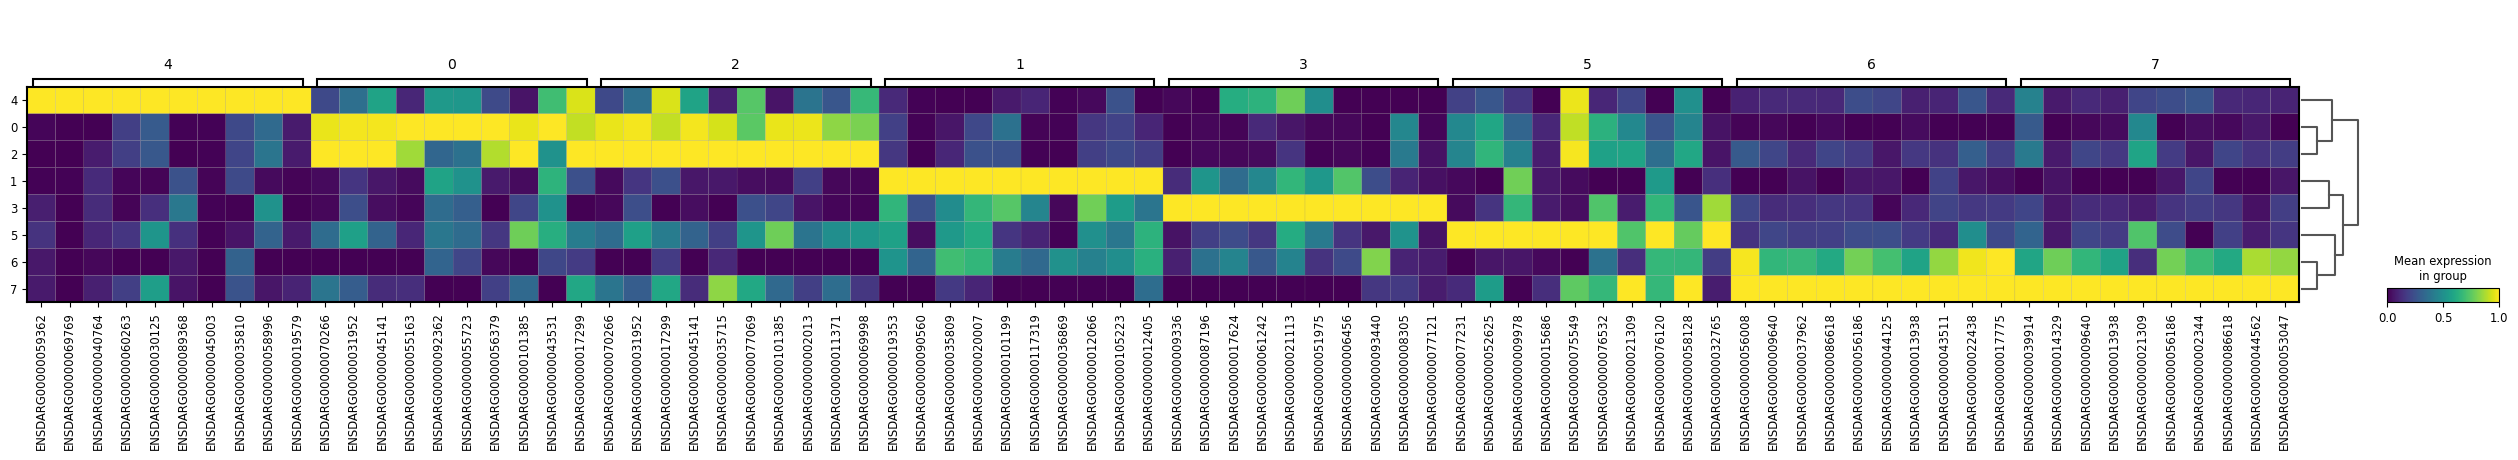

In [11]:
sc.pl.rank_genes_groups_matrixplot(adata, standard_scale='var', n_genes=10, key=rank_genes_column, show=True)

## Create suitable marker list(s)

The paths of the marker lists will be stored in the <b>marker_lists</b> variable. They will work as input for the actual cell type annotation of the next cell. 

No marker lists found for this organism.
Trying to create marker lists via homology...
Fetching whitelists...
Done!

Loading genes of zebrafish...
Done!

Select lists of source markers.
Available columns for search:
1: List name
2: Marker type
3: Organism name
4: Taxonomy ID
5: Submitter name
6: List type
7: Source
8: tags_transferred
9: Date
10: Email
n: Next page
Enter identifier of column to search in (leave blank to search in all columns): 
Enter search terms (separated by commas, '-' for negative search): panglao.se
Perform an exact search? (yes/no): yes
Consider case sensitivity? (yes/no): yes
Number of results: 60
Do you want to see the results? (yes/no): no
Do you want to continue searching? (yes/no): no

The following source organisms can be used in both approaches: human 9606, mouse 10090.

Starting HomoloGene approach...
Loading genes of human...
Done!

Get HomoloGene db...

DataFrame of the markers of the source organism (human) to be transferred to the target organism (zeb

,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,AGRP ENSG00000159723,Chromaffin cells
2,IGF2 ENSG00000167244,Chromaffin cells
3,SNAP25 ENSG00000132639,Chromaffin cells
4,SLC18A2 ENSG00000165646,Chromaffin cells
...,...,...
8045,PIWIL1 ENSG00000125207,Embryonic stem cells
8046,PIWIL2 ENSG00000197181,Embryonic stem cells
8047,PIWIL4 ENSG00000134627,Embryonic stem cells
8048,LIFR ENSG00000113594,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.
Marker transfer rate: 79.43%
Marker transfer rate after filtering: 60.17%
Possible transfer rate of all genes: 23.07%
Proportion of transferred genes in all genes of target organism: 31.58%

Count of target genes per source gene:


,Source Gene,Count target genes
12026,ZNF729 ENSG00000196350,655
7444,PCDHB3 ENSG00000113205,63
7442,PCDHA8 ENSG00000204962,40
4651,HIST2H2BE,31
7237,OR8G5 ENSG00000255298,25
...,...,...
4293,GPR142 ENSG00000257008,1
4294,GPR143 ENSG00000101850,1
4295,GPR144,1
4296,GPR146 ENSG00000164849,1


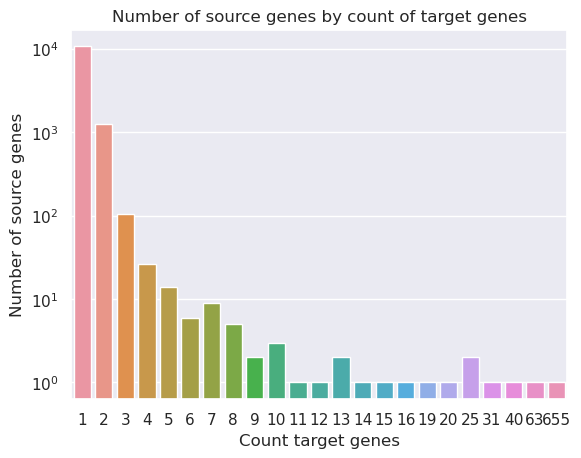

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,SLC26A4 ENSG00000091137,Platelets
2,SLC26A4 ENSG00000091137,Intercalated cells
3,SLC26A4 ENSG00000091137,Transient cells
4,SNAP25 ENSG00000132639,Chromaffin cells
...,...,...
4116,TAF8 ENSG00000137413,Embryonic stem cells
4117,NACC1 ENSG00000160877,Embryonic stem cells
4118,GDF3 ENSG00000184344,Embryonic stem cells
4119,SMAD2 ENSG00000175387,Embryonic stem cells


Filtered: 3929 source genes, 48.81%
Create DataFrame containing the transferred genes based on the filter criteria.
Marker transfer rate: 100.00%
Marker transfer rate after filtering: 83.01%
Possible transfer rate of all genes: 23.07%
Proportion of transferred genes in all genes of target organism: 31.58%
Transferred markers:


,Marker,Info
0,SLC26A4 ENSDARG00000069431,Chromaffin cells
1,SLC26A4 ENSDARG00000069431,Platelets
2,SLC26A4 ENSDARG00000069431,Intercalated cells
3,SLC26A4 ENSDARG00000069431,Transient cells
4,SNAP25A ENSDARG00000020609,Chromaffin cells
...,...,...
4116,TAF8 ENSDARG00000026806,Embryonic stem cells
4117,LOC572093,Embryonic stem cells
4118,DVR1,Embryonic stem cells
4119,SMAD2 ENSDARG00000006389,Embryonic stem cells


Weighted transferred markers:


,Marker,Info,Score
4120,PIWIL1 ENSDARG00000041699,Embryonic stem cells,0.0
2938,CRELD2 ENSDARG00000029071,B cells,0.0
2941,EDEM2 ENSDARG00000028448,B cells,0.0
1178,CUL5B ENSDARG00000004260,Immature neurons,0.0
1177,STIM2B ENSDARG00000001776,Immature neurons,0.0
...,...,...,...
1229,ISL1 ENSDARG00000004023,Interneurons,1.0
1241,ISL1 ENSDARG00000004023,Satellite cells,1.0
1240,ISL1 ENSDARG00000004023,Pancreatic progenitor cells,1.0
1236,ISL1 ENSDARG00000004023,Cardiac stem and precursor cells,1.0


Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/human_zebrafish_HomoloGene_annotation_20230816122525
Loading genes of mouse...
Done!

Get HomoloGene db...

DataFrame of the markers of the source organism (mouse) to be transferred to the target organism (zebrafish):


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,AGRP ENSMUSG00000005705,Chromaffin cells
2,IGF2 ENSMUSG00000048583,Chromaffin cells
3,SNAP25 ENSMUSG00000027273,Chromaffin cells
4,SLC18A2 ENSMUSG00000025094,Chromaffin cells
...,...,...
8079,PIWIL2 ENSMUSG00000033644,Embryonic stem cells
8080,PIWIL4 ENSMUSG00000036912,Embryonic stem cells
8081,LIFR ENSMUSG00000054263,Embryonic stem cells
8082,IL6ST ENSMUSG00000021756,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.
Marker transfer rate: 79.21%
Marker transfer rate after filtering: 59.95%
Possible transfer rate of all genes: 25.35%
Proportion of transferred genes in all genes of target organism: 32.30%

Count of target genes per source gene:


,Source Gene,Count target genes
185,AA987161,655
12048,ZFP738 ENSMUSG00000048280,655
179,A530054K11RIK,655
7526,PCDHB3 ENSMUSG00000045498,63
7301,OLFR935 ENSMUSG00000059595,25
...,...,...
4325,GMIP ENSMUSG00000036246,1
4326,GMNC ENSMUSG00000068428,1
4327,GMNN ENSMUSG00000006715,1
4328,GMPPA ENSMUSG00000033021,1


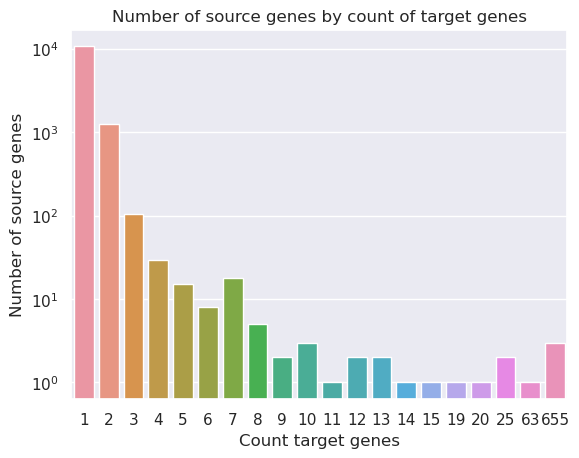

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,SLC26A4 ENSMUSG00000020651,Platelets
2,SLC26A4 ENSMUSG00000020651,Intercalated cells
3,SLC26A4 ENSMUSG00000020651,Transient cells
4,SNAP25 ENSMUSG00000027273,Chromaffin cells
...,...,...
4136,HMGA2 ENSMUSG00000056758,Embryonic stem cells
4137,NACC1 ENSMUSG00000001910,Embryonic stem cells
4138,GDF3 ENSMUSG00000030117,Embryonic stem cells
4139,SMAD2 ENSMUSG00000024563,Embryonic stem cells


Filtered: 3943 source genes, 48.78%
Create DataFrame containing the transferred genes based on the filter criteria.
Marker transfer rate: 99.90%
Marker transfer rate after filtering: 82.81%
Possible transfer rate of all genes: 25.35%
Proportion of transferred genes in all genes of target organism: 32.30%
Transferred markers:


,Marker,Info
0,SLC26A4 ENSDARG00000069431,Chromaffin cells
1,SLC26A4 ENSDARG00000069431,Platelets
2,SLC26A4 ENSDARG00000069431,Intercalated cells
3,SLC26A4 ENSDARG00000069431,Transient cells
4,SNAP25A ENSDARG00000020609,Chromaffin cells
...,...,...
4136,HMGA2 ENSDARG00000069912,Embryonic stem cells
4137,LOC572093,Embryonic stem cells
4138,DVR1,Embryonic stem cells
4139,SMAD2 ENSDARG00000006389,Embryonic stem cells


Weighted transferred markers:


,Marker,Info,Score
4140,PIWIL1 ENSDARG00000041699,Embryonic stem cells,0.0
2952,DNTT ENSDARG00000104792,B cells,0.0
2955,EDEM1 ENSDARG00000025094,B cells,0.0
2956,CRELD2 ENSDARG00000029071,B cells,0.0
1183,CUL5B ENSDARG00000004260,Immature neurons,0.0
...,...,...,...
1237,ISL1 ENSDARG00000004023,Neurons,1.0
1236,ISL1 ENSDARG00000004023,Neuroblasts,1.0
1235,ISL1 ENSDARG00000004023,Motor neurons,1.0
1242,ISL1 ENSDARG00000004023,Beta cells,1.0


Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/mouse_zebrafish_HomoloGene_annotation_20230816122530

Starting BioMart approach...

Specify BioMart target organism selection:
Selection: drerio


Specify BioMart source organism selection:
Selection: hsapiens

Loading genes of human...
Done!

Fetch necessary data from BioMart...

DataFrame of the markers of the source organism (human) to be transferred to the target organism (zebrafish):


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,AGRP ENSG00000159723,Chromaffin cells
2,IGF2 ENSG00000167244,Chromaffin cells
3,SNAP25 ENSG00000132639,Chromaffin cells
4,SLC18A2 ENSG00000165646,Chromaffin cells
...,...,...
8045,PIWIL1 ENSG00000125207,Embryonic stem cells
8046,PIWIL2 ENSG00000197181,Embryonic stem cells
8047,PIWIL4 ENSG00000134627,Embryonic stem cells
8048,LIFR ENSG00000113594,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.
Marker transfer rate: 130.17%
Marker transfer rate after filtering: 128.94%
Possible transfer rate of all genes: 35.96%
Proportion of transferred genes in all genes of target organism: 67.35%

Count of target genes per source gene:


,Source Gene,Count target genes
76,CD22 ENSG00000012124,35
922,HTRA2 ENSG00000115317,25
770,MS4A6A ENSG00000110077,24
2379,MS4A7 ENSG00000166927,24
2380,MS4A5 ENSG00000166930,24
...,...,...
1309,MNX1 ENSG00000130675,1
1310,GATA5 ENSG00000130700,1
1311,LAMA5 ENSG00000130702,1
1312,ASS1 ENSG00000130707,1


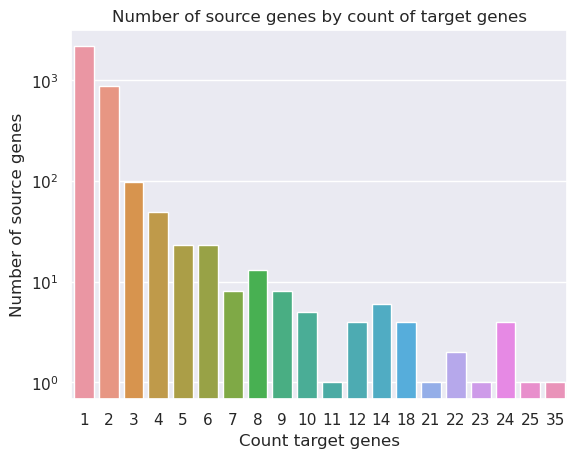

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSG00000091137,Chromaffin cells
1,SLC26A4 ENSG00000091137,Platelets
2,SLC26A4 ENSG00000091137,Intercalated cells
3,SLC26A4 ENSG00000091137,Transient cells
4,AGRP ENSG00000159723,Chromaffin cells
...,...,...
3709,LMNA ENSG00000160789,Embryonic stem cells
3710,TAF8 ENSG00000137413,Embryonic stem cells
3711,HMGA2 ENSG00000149948,Embryonic stem cells
3712,ESRRB ENSG00000119715,Embryonic stem cells


Filtered: 4336 source genes, 53.86%
Create DataFrame containing the transferred genes based on the filter criteria.
Marker transfer rate: 100.00%
Marker transfer rate after filtering: 99.00%
Possible transfer rate of all genes: 35.96%
Proportion of transferred genes in all genes of target organism: 67.35%
Transferred markers:


,Marker,Info
0,CRYL1 ENSDARG00000003675,Proximal tubule cells
1,CLDN17 ENSDARG00000099950,Distal tubule cells
2,CLDN17 ENSDARG00000099950,Loop of Henle cells
3,CBY1 ENSDARG00000077409,Germ cells
4,POU4F1 ENSDARG00000005559,Retinal ganglion cells
...,...,...
3709,RYR2B ENSDARG00000003706,Neurons
3710,RYR2B ENSDARG00000003706,Cardiomyocytes
3711,CSF3R ENSDARG00000045959,Microglia
3712,CSF3R ENSDARG00000045959,Monocytes


Weighted transferred markers:


,Marker,Info,Score
0,CRYL1 ENSDARG00000003675,Proximal tubule cells,0.0
2506,TMEM53 ENSDARG00000038789,Germ cells,0.0
1078,KLHL2 ENSDARG00000061786,Oligodendrocytes,0.0
2510,NOX5 ENSDARG00000079773,Platelets,0.0
2514,KCNQ3 ENSDARG00000060085,Pyramidal cells,0.0
...,...,...,...
1971,SI:DKEY-30C15.12 ENSDARG00000058546,Satellite cells,1.0
1972,SI:DKEY-30C15.12 ENSDARG00000058546,Sebocytes,1.0
1973,SI:DKEY-30C15.12 ENSDARG00000058546,Embryonic stem cells,1.0
1966,SI:DKEY-30C15.12 ENSDARG00000058546,Hepatoblasts,1.0


Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/human_zebrafish_BioMart_annotation_20230816122537

Specify BioMart source organism selection:
Default organism: mmusculus
Loading genes of mouse...
Done!

Fetch necessary data from BioMart...

DataFrame of the markers of the source organism (mouse) to be transferred to the target organism (zebrafish):


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,AGRP ENSMUSG00000005705,Chromaffin cells
2,IGF2 ENSMUSG00000048583,Chromaffin cells
3,SNAP25 ENSMUSG00000027273,Chromaffin cells
4,SLC18A2 ENSMUSG00000025094,Chromaffin cells
...,...,...
8079,PIWIL2 ENSMUSG00000033644,Embryonic stem cells
8080,PIWIL4 ENSMUSG00000036912,Embryonic stem cells
8081,LIFR ENSMUSG00000054263,Embryonic stem cells
8082,IL6ST ENSMUSG00000021756,Embryonic stem cells


Filter source DataFrame by the number of target genes per source gene: remove all source genes that lead to more than 1 target genes.
Marker transfer rate: 127.68%
Marker transfer rate after filtering: 126.46%
Possible transfer rate of all genes: 41.89%
Proportion of transferred genes in all genes of target organism: 71.67%

Count of target genes per source gene:


,Source Gene,Count target genes
3227,TRAC ENSMUSG00000076928,37
1700,CD22 ENSMUSG00000030577,35
3226,TRDV1 ENSMUSG00000076864,32
3139,HTRA2 ENSMUSG00000068329,25
999,MS4A7 ENSMUSG00000024672,24
...,...,...
1329,SNX16 ENSMUSG00000027534,1
1330,NFATC2 ENSMUSG00000027544,1
1331,SALL4 ENSMUSG00000027547,1
1335,COL9A3 ENSMUSG00000027570,1


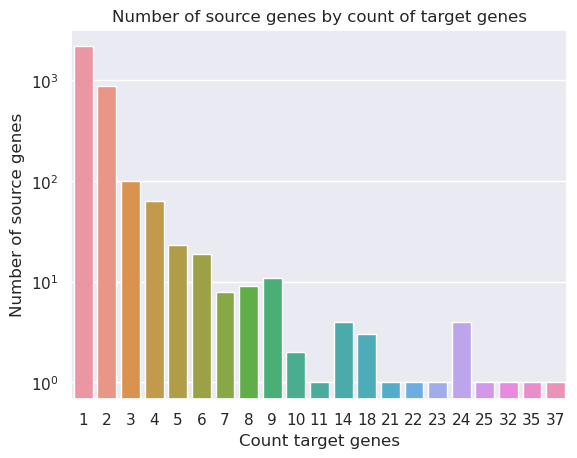

Filtered source DataFrame with target_counts <= 1:


,Marker,Info
0,SLC26A4 ENSMUSG00000020651,Chromaffin cells
1,SLC26A4 ENSMUSG00000020651,Platelets
2,SLC26A4 ENSMUSG00000020651,Intercalated cells
3,SLC26A4 ENSMUSG00000020651,Transient cells
4,AGRP ENSMUSG00000005705,Chromaffin cells
...,...,...
3735,TAF8 ENSMUSG00000023980,Embryonic stem cells
3736,HMGA2 ENSMUSG00000056758,Embryonic stem cells
3737,ESRRB ENSMUSG00000021255,Embryonic stem cells
3738,PIWIL1 ENSMUSG00000029423,Embryonic stem cells


Filtered: 4344 source genes, 53.74%
Create DataFrame containing the transferred genes based on the filter criteria.
Marker transfer rate: 100.00%
Marker transfer rate after filtering: 99.01%
Possible transfer rate of all genes: 41.89%
Proportion of transferred genes in all genes of target organism: 71.67%
Transferred markers:


,Marker,Info
0,CDH2 ENSDARG00000018693,Hematopoietic stem cells
1,HGD ENSDARG00000058005,Proximal tubule cells
2,DSC2L ENSDARG00000039677,Keratinocytes
5,SI:CH73-74H11.1 ENSDARG00000062750,Trichocytes
6,LMNB1 ENSDARG00000044299,Erythroblasts
...,...,...
3735,EHF ENSDARG00000052115,Delta cells
3736,EHF ENSDARG00000052115,Langerhans cells
3737,SPRED1 ENSDARG00000041449,Mast cells
3738,LRRC57 ENSDARG00000043938,Germ cells


Weighted transferred markers:


,Marker,Info,Score
0,CDH2 ENSDARG00000018693,Hematopoietic stem cells,0.0
1868,SLC7A7 ENSDARG00000055226,Macrophages,0.0
1865,RAB30 ENSDARG00000037884,Dendritic cells,0.0
3738,LRRC57 ENSDARG00000043938,Germ cells,0.0
1861,CADPS2 ENSDARG00000013312,Dopaminergic neurons,0.0
...,...,...,...
163,SI:DKEY-30C15.12 ENSDARG00000058546,Mammary epithelial cells,1.0
164,SI:DKEY-30C15.12 ENSDARG00000058546,Satellite cells,1.0
166,SI:DKEY-30C15.12 ENSDARG00000058546,Embryonic stem cells,1.0
158,SI:DKEY-30C15.12 ENSDARG00000058546,Plasmacytoid dendritic cells,1.0


Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/mouse_zebrafish_BioMart_annotation_20230816122542

Finished!
Do you want to add another marker list? (yes/no): no


In [13]:
marker_lists = wrap.create_marker_lists(organism, repo_path=repo_path, style="score", file_name=organism, ensembl=True)

## Annotate adata using the created list(s)

Output folder: ./annotation/human_zebrafish_HomoloGene_annotation_20230816122525/ranked/output/leiden/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/human_zebrafish_HomoloGene_annotation_20230816122525 
Cluster folder: ./annotation/human_zebrafish_HomoloGene_annotation_20230816122525/ranked/clusters/leiden/ 
Tissue: all
Created folder: ./annotation/human_zebrafish_HomoloGene_annotation_20230816122525/ranked/clusters/leiden
Created folder: ./annotation/human_zebrafish_HomoloGene_annotation_20230816122525/ranked/output/leiden
Writing one file per cluster containing gene names and ranked gene scores.
Starting cell type annotation.
./annotation/human_zebrafish_HomoloGene_annotation_20230816122525 ./annotation/human_zebrafish_HomoloGene_annotation_20230816122525/ranked/output/leiden leiden
The database contains 2330 different genes.          
The input data contains 17832 different genes.          
The genes of the input data overlap

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


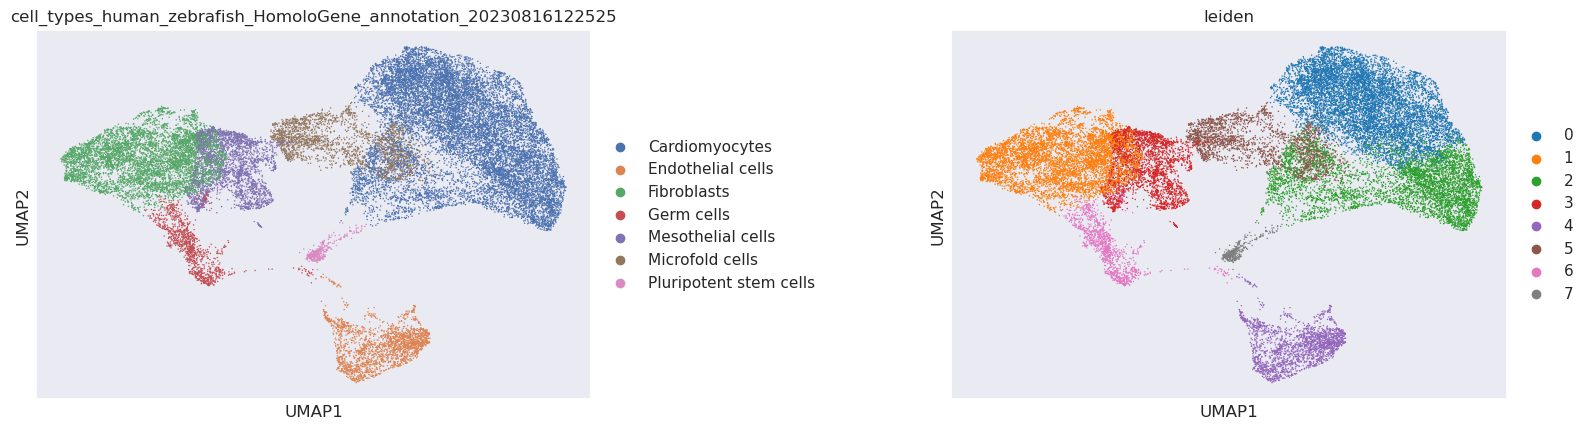

Tables of cell type annotation with clustering leiden


,Cluster 0: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,879,53,69,14
1,Endothelial cells,431,69,95,14
2,Pyramidal cells,249,6,22,7
3,Enterocytes,183,39,81,11
4,Megakaryocytes,93,19,30,3


,Cluster 2: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,739,53,69,14
1,Endothelial cells,636,69,95,14
2,Pyramidal cells,439,6,22,7
3,Enterocytes,411,39,81,11
4,B cells,167,19,30,13


,Cluster 5: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Microfold cells,417,10,17,14
1,Podocytes,363,42,64,15
2,B cells,361,19,30,13
3,Transient cells,321,11,16,21
4,T cells,320,18,30,11


,Cluster 4: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1544,69,95,14
1,Erythroblasts,405,12,16,15
2,Microfold cells,327,10,17,14
3,Monocytes,303,18,23,12
4,Pancreatic progenitor cells,276,8,13,6


...

,Cluster 1: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Fibroblasts,1301,78,101,8
1,Epiblast cells,986,5,8,20
2,Neuroendocrine cells,774,9,19,22
3,Plasma cells,756,16,26,17
4,Myocytes,732,33,53,11


,Cluster 6: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Germ cells,1047,33,53,22
1,Pluripotent stem cells,948,8,13,21
2,Gamma delta T cells,822,13,15,27
3,Goblet cells,744,8,14,13
4,Anterior pituitary gland cells,554,10,21,23


,Cluster 7: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pluripotent stem cells,709,8,13,21
1,Germ cells,649,33,53,22
2,Pyramidal cells,465,6,22,7
3,T cells,336,18,30,11
4,Myoepithelial cells,276,8,14,5


Output folder: ./annotation/mouse_zebrafish_HomoloGene_annotation_20230816122530/ranked/output/leiden/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/mouse_zebrafish_HomoloGene_annotation_20230816122530 
Cluster folder: ./annotation/mouse_zebrafish_HomoloGene_annotation_20230816122530/ranked/clusters/leiden/ 
Tissue: all
Created folder: ./annotation/mouse_zebrafish_HomoloGene_annotation_20230816122530/ranked/clusters/leiden
Created folder: ./annotation/mouse_zebrafish_HomoloGene_annotation_20230816122530/ranked/output/leiden
Writing one file per cluster containing gene names and ranked gene scores.
Starting cell type annotation.
./annotation/mouse_zebrafish_HomoloGene_annotation_20230816122530 ./annotation/mouse_zebrafish_HomoloGene_annotation_20230816122530/ranked/output/leiden leiden
The database contains 2339 different genes.          
The input data contains 17832 different genes.          
The genes of the input data overlap

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


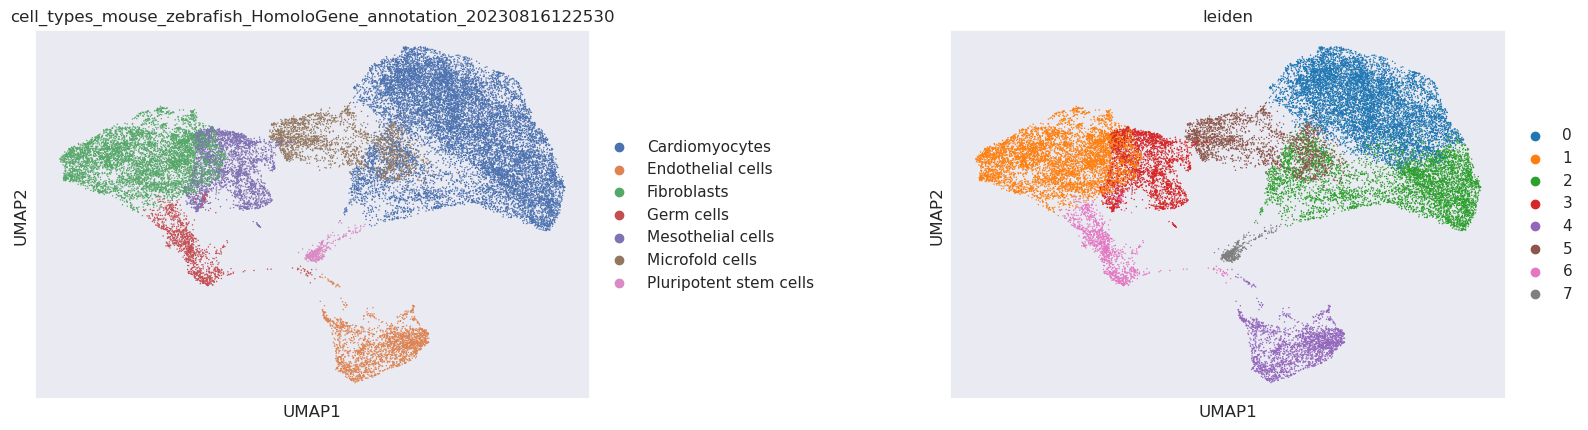

Tables of cell type annotation with clustering leiden


,Cluster 0: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,918,51,67,13
1,Endothelial cells,439,70,94,15
2,Pyramidal cells,249,6,23,7
3,Enterocytes,200,39,78,10
4,Megakaryocytes,93,19,30,3


,Cluster 2: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,712,51,67,13
1,Endothelial cells,644,70,94,15
2,Pyramidal cells,439,6,23,7
3,Enterocytes,417,39,78,10
4,Retinal ganglion cells,166,20,40,28


,Cluster 5: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Microfold cells,417,10,17,14
1,B cells,399,23,34,13
2,Transient cells,321,11,16,21
3,T cells,320,18,30,11
4,B cells naive,268,14,22,11


,Cluster 4: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1600,70,94,15
1,Erythroblasts,405,12,16,15
2,Microfold cells,327,10,17,14
3,Monocytes,310,17,21,13
4,Pancreatic progenitor cells,276,8,14,6


...

,Cluster 1: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Fibroblasts,1295,79,103,8
1,Epiblast cells,986,5,9,20
2,Plasma cells,876,14,22,15
3,Neuroendocrine cells,774,9,19,22
4,Müller cells,733,22,32,13


,Cluster 6: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Germ cells,1058,32,54,23
1,Pluripotent stem cells,948,8,13,21
2,Goblet cells,744,8,15,13
3,Anterior pituitary gland cells,554,10,22,23
4,Neurons,496,60,118,15


,Cluster 7: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pluripotent stem cells,709,8,13,21
1,Germ cells,657,32,54,23
2,Pyramidal cells,465,6,23,7
3,T cells,336,18,30,11
4,Myoepithelial cells,295,7,13,6


Output folder: ./annotation/human_zebrafish_BioMart_annotation_20230816122537/ranked/output/leiden/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/human_zebrafish_BioMart_annotation_20230816122537 
Cluster folder: ./annotation/human_zebrafish_BioMart_annotation_20230816122537/ranked/clusters/leiden/ 
Tissue: all
Created folder: ./annotation/human_zebrafish_BioMart_annotation_20230816122537/ranked/clusters/leiden
Created folder: ./annotation/human_zebrafish_BioMart_annotation_20230816122537/ranked/output/leiden
Writing one file per cluster containing gene names and ranked gene scores.
Starting cell type annotation.
./annotation/human_zebrafish_BioMart_annotation_20230816122537 ./annotation/human_zebrafish_BioMart_annotation_20230816122537/ranked/output/leiden leiden
The database contains 2121 different genes.          
The input data contains 17832 different genes.          
The genes of the input data overlap with 1511 genes in t

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


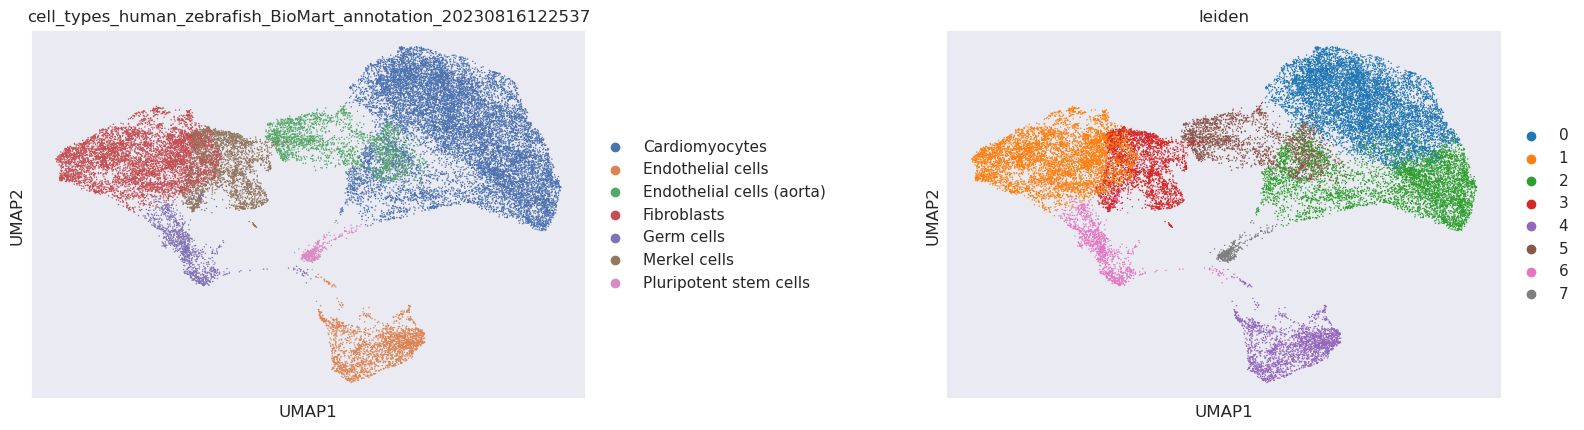

Tables of cell type annotation with clustering leiden


,Cluster 0: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,781,51,56,13
1,Dopaminergic neurons,268,5,12,14
2,T regulatory cells,241,5,8,9
3,Enterocytes,231,44,83,13
4,Tuft cells,198,9,17,9


,Cluster 2: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,676,51,56,13
1,Enterocytes,494,44,83,13
2,Endothelial cells,346,82,93,15
3,Dopaminergic neurons,265,5,12,14
4,Transient cells,219,9,14,22


,Cluster 5: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells (aorta),392,45,47,15
1,T cells,391,26,34,11
2,Purkinje neurons,335,25,33,17
3,Microfold cells,320,8,16,14
4,Mesangial cells,287,33,34,15


,Cluster 4: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1692,82,93,15
1,Tuft cells,473,9,17,9
2,Acinar cells,410,8,12,10
3,Erythroblasts,391,14,16,11
4,Merkel cells,256,6,11,8


...

,Cluster 1: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Fibroblasts,1322,73,84,8
1,Müller cells,901,16,22,10
2,Plasma cells,762,20,27,19
3,Pancreatic stellate cells,723,12,13,5
4,Melanocytes,707,14,23,15


,Cluster 6: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Germ cells,1299,47,64,23
1,Pluripotent stem cells,1033,7,14,24
2,Gamma delta T cells,821,15,18,26
3,Goblet cells,689,10,16,12
4,B cells,600,23,31,12


,Cluster 7: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Pluripotent stem cells,756,7,14,24
1,Germ cells,743,47,64,23
2,Pyramidal cells,547,8,16,6
3,T cells,327,26,34,11
4,Reticulocytes,251,6,6,12


Output folder: ./annotation/mouse_zebrafish_BioMart_annotation_20230816122542/ranked/output/leiden/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/transferred_markers/mouse_zebrafish_BioMart_annotation_20230816122542 
Cluster folder: ./annotation/mouse_zebrafish_BioMart_annotation_20230816122542/ranked/clusters/leiden/ 
Tissue: all
Created folder: ./annotation/mouse_zebrafish_BioMart_annotation_20230816122542/ranked/clusters/leiden
Created folder: ./annotation/mouse_zebrafish_BioMart_annotation_20230816122542/ranked/output/leiden
Writing one file per cluster containing gene names and ranked gene scores.
Starting cell type annotation.
./annotation/mouse_zebrafish_BioMart_annotation_20230816122542 ./annotation/mouse_zebrafish_BioMart_annotation_20230816122542/ranked/output/leiden leiden
The database contains 2126 different genes.          
The input data contains 17832 different genes.          
The genes of the input data overlap with 1515 genes in t

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


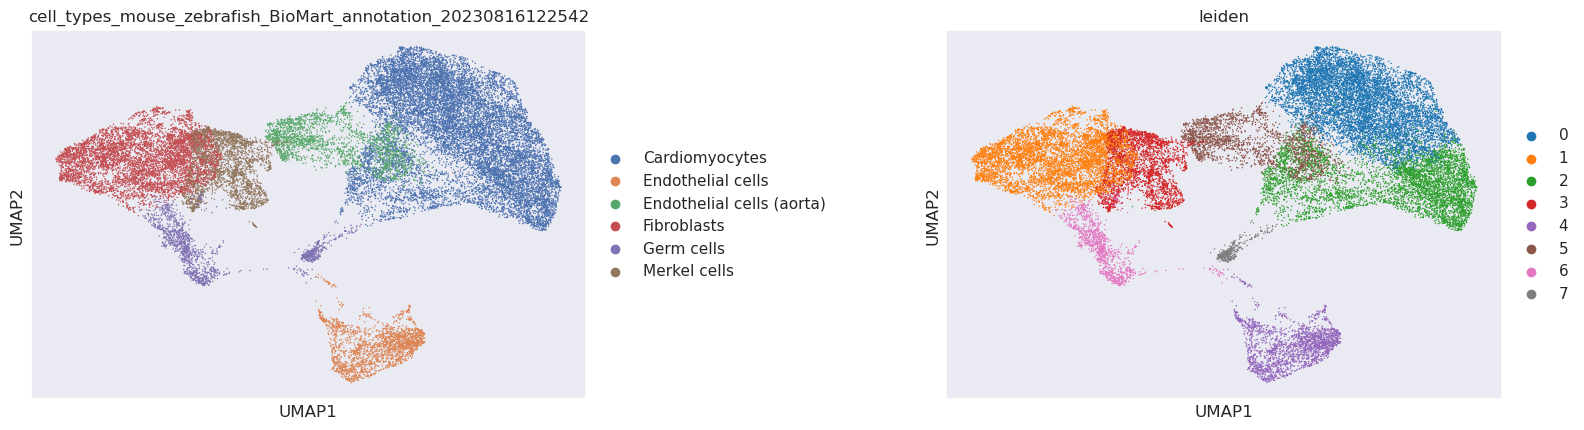

Tables of cell type annotation with clustering leiden


,Cluster 0: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,602,52,57,14
1,Dopaminergic neurons,268,5,12,14
2,Enterocytes,256,42,80,12
3,T regulatory cells,241,5,8,9
4,Macrophages,103,31,43,12


,Cluster 2: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Cardiomyocytes,694,52,57,14
1,Enterocytes,500,42,80,12
2,Endothelial cells,349,82,92,15
3,Dopaminergic neurons,265,5,12,14
4,Transient cells,219,9,15,22


,Cluster 5: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells (aorta),392,46,48,14
1,T cells,391,26,34,11
2,Microfold cells,320,8,16,14
3,Basal cells,306,19,25,17
4,Mesangial cells,287,33,35,15


,Cluster 4: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1749,82,92,15
1,Erythroblasts,391,14,16,11
2,Monocytes,337,21,26,11
3,Tuft cells,317,11,19,11
4,Merkel cells,251,5,10,9


,Cluster 3: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Merkel cells,1049,5,10,9
1,Hepatocytes,813,41,75,19
2,Pancreatic stellate cells,804,13,14,5
3,Proximal tubule cells,803,28,46,18
4,Mesothelial cells,788,19,20,14


,Cluster 1: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Fibroblasts,1224,73,84,7
1,Müller cells,905,16,23,11
2,Plasma cells,863,18,24,18
3,Melanocytes,746,12,20,15
4,Pancreatic stellate cells,713,13,14,5


,Cluster 6: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Germ cells,1258,47,64,23
1,Pluripotent stem cells,1033,7,13,24
2,Goblet cells,689,10,15,12
3,B cells,498,26,34,12
4,Gamma delta T cells,489,14,17,26


,Cluster 7: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Germ cells,843,47,64,23
1,Pluripotent stem cells,756,7,13,24
2,Pyramidal cells,547,8,15,6
3,T cells,327,26,34,11
4,Reticulocytes,251,6,6,12


In [14]:
for marker_list in marker_lists:
    name = marker_list.split("/")[-1]
    annotation_dir = f"./annotation/{name}"
    
    # Annotate
    annot.annot_ct(adata, output_path=annotation_dir, db_path=marker_list,
                   cluster_column=f"{column}", rank_genes_column=rank_genes_column, 
                   ct_column=f"cell_types_{name}")
    
    # Plot annotation
    sc.pl.umap(adata, color=[f'cell_types_{name}', f'{column}'], wspace=0.5)

    # Show scores and alternate cell types of eacht cluster
    print(f"Tables of cell type annotation with clustering {column}")
    annot.show_tables(annotation_dir=annotation_dir, n=5, clustering_column=column)